In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [15]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export_sta584.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7738 entries, 0 to 7737
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  7738 non-null   str  
 1   Message  7738 non-null   str  
 2   Status   7738 non-null   str  
dtypes: str(3)
memory usage: 181.5 KB


In [16]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [17]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  Series([], Name: Created, dtype: str) Last fuel report fs02:  2026-09-09 15:40:46.203


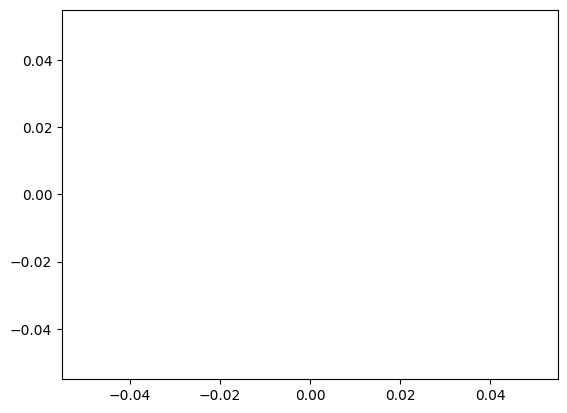

In [18]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

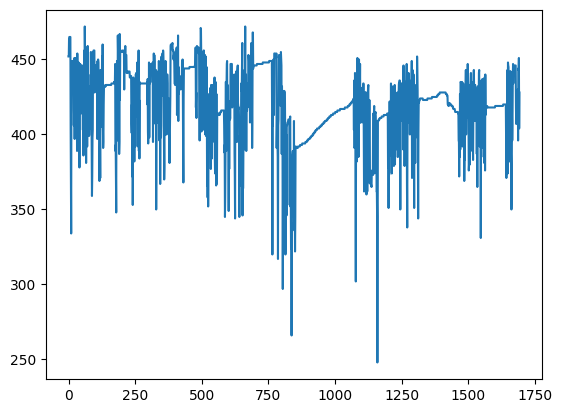

In [19]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [20]:
for i in range(0,values_dates_fs01.shape[0]):
    if int(values_dates_fs01.iloc[i,0])>4095:
        print(values_dates_fs01.iloc[i,2])

In [21]:
for i in range(0,values_dates_fs02.shape[0]):
    if int(values_dates_fs02.iloc[i,0])>4095:
        print(values_dates_fs01.iloc[i,2])

In [22]:
gallons_fs01=[] #Editable
gallons_fs02=[] #Editable
m1=0.1302       #Editable
b1=18.902       #Editable
m2=0.0529       #Editable
b2=5.2153       #Editable

values_dates_fs01_ordered.info()

for i in range(0,values_dates_fs01_ordered.shape[0]):
    gallons_value_fs01=(float(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)
    gallons_fs01.append(gallons_value_fs01) 
    #print(i,values_dates_fs01_ordered.iloc[i,2][32:44],(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)

for i in range(0,values_dates_fs02_ordered.shape[0]):
    gallons_value_fs02=(float(values_dates_fs02_ordered.iloc[i,0]*m2-b2)/3.785412)
    gallons_fs02.append(gallons_value_fs02)  
    #print(i,values_dates_fs02_ordered.iloc[i,2][32:44],(values_dates_fs02_ordered.iloc[i,0]*m1-b1)/3.785412)

values_dates_fs01_ordered['gallons']=gallons_fs01
values_dates_fs02_ordered['gallons']=gallons_fs02

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   value     0 non-null      float64
 1   date      0 non-null      float64
 2   raw data  0 non-null      float64
dtypes: float64(3)
memory usage: 132.0 bytes


In [23]:
capacity_1=135      #Editable
capacity_2=55       #Editable
level=0
p=0 # If vahice is parked, p=0

date1=260819164716  #Editable
date2=260819171251  #Editable

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>=(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
        if values_dates_fs01_ordered.iloc[i+1,3]<=(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>=(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)
        if values_dates_fs02_ordered.iloc[i+1,3]<=(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta
Level change tank 1:  0
Level change tank 1 + Level change tank 2: 
Level change toal:  0


Adding the validation to delete the value that beongs to ragistger i+1.

In [24]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260819164716
date2=260819171251
level=0

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3])
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
Level change tank 1:  0
Level change tank 1 + Level change tank 2: 
Level change toal:  0


In [25]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260819164716
date2=260819171251
level=0

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
Level change tank 1:  0
Level change tank 1 + Level change tank 2: 
Level change toal:  0
